In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from nanonets import Simulation
from nanonets.utils import get_displacement_currents, get_tau_f0_SET
from matplotlib.colors import Normalize
from scipy.optimize import curve_fit
from scipy.special import gamma
from matplotlib.colors import LogNorm
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors

plt.style.use(["science","bright","grid"])

TIME_STEP   = 1.5e-11
STAT_SIZE   = 500
L           = 9
CPU_CNT     = 32
T_WRITE     = 102.4
T_WAITS     = [0.0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,204.8,409.6,819.2,1638.4,3276.8,6553.6]
R_VALUES    = [50,100,200,400,800,1600]
V_WRITES    = 0.0195
N_VOLT      = 50000
CMAP        = plt.get_cmap('cividis')
FOLDER      = "/home/jonasmensing/bagheera/data/2_funding_period/dynamic/DC/two_steps_res/"
N_PARTICLES = 9
ELE_AC      = 0.160217662
TAU_SET, F0_SET = get_tau_f0_SET()
def get_lattice_electrode_cap_matrix(L: int):
    topo = {"Nx": L,"Ny": L,
            "e_pos": [[(L-1)//2, 0],[0, 0],[L-1, 0],
                    [0, (L-1)//2],[L-1, (L-1)//2],
                    [0, L-1],[L-1, L-1],[(L-1)//2, L-1]],
            "electrode_type": ['constant']*8}
    sim  = Simulation(topo)
    return sim.get_electrode_capacitance_matrix()
def lin_func(x, a, b, c):
    return a*(x-b) + c
def stretched_exp(t, tau, beta, I0):
    return I0*np.exp(-(t/tau)**beta)
def exp_decay(t, tau, A):
    return 1 + A*np.exp(-t/tau)
topo = {"Nx": N_PARTICLES,"Ny": N_PARTICLES,
        "e_pos": [[(N_PARTICLES-1)//2, 0],[0, 0],[N_PARTICLES-1, 0],
                [0, (N_PARTICLES-1)//2],[N_PARTICLES-1, (N_PARTICLES-1)//2],
                [0, N_PARTICLES-1],[N_PARTICLES-1, N_PARTICLES-1],[(N_PARTICLES-1)//2, N_PARTICLES-1]],
        "electrode_type": ['constant']*8}
sim_class = Simulation(topo)
cap_mat   = sim_class.get_capacitance_matrix()
cap_mat_e = sim_class.get_electrode_capacitance_matrix()
C_US      = get_lattice_electrode_cap_matrix(L).T

In [7]:
def paired_pulse(V_write, t_write, t_wait, dt, N_electrodes=8, input_pos=0):
    
    # 1. Convert times to integer number of steps (force symmetry)
    # Using round() ensures we grab the nearest valid step count
    n_write = int(np.round(t_write / dt))
    n_wait  = int(np.round(t_wait / dt))
    
    # 2. Total simulation length
    # Note: We enforce the second pulse is exactly n_write long
    n_total = n_write + n_wait + n_write 
    
    # 3. Create Time Series
    t_series = np.arange(0, n_total+1) * dt
    
    # 4. Create Voltage Vector (default 0)
    V_signal = np.zeros(n_total)
    
    # 5. Assign Pulse 1 (Indices 0 to n_write)
    V_signal[0 : n_write] = V_write
    
    # 6. Assign Pulse 2 (Indices start after wait)
    # Start: n_write + n_wait
    # End:   n_write + n_wait + n_write
    start_2 = n_write + n_wait
    end_2   = start_2 + n_write
    V_signal[start_2 : end_2] = V_write

    # 7. Map to Electrodes
    voltages = np.zeros((n_total, N_electrodes+1))
    voltages[:, input_pos] = V_signal

    return t_series, voltages

### Load from Cluster

In [16]:
def state_memory(x, y):

    # Get Wait Indices
    idx_wait = np.where(x == 0.0)[0]
    if len(idx_wait) != 0:
        t1_end = idx_wait[0] - 1
        t2_sta = idx_wait[-1] + 1
    else:
        t1_end  = len(x)//2 - 1
        t2_sta  = len(x)//2

    # State vectors
    s0  = y.copy()[0,:]
    s1  = y.copy()[t1_end,:]
    s2  = y.copy()[t2_sta,:]
    s3  = y.copy()[-1,:]
        
    # Pulse Responses          
    R1  = np.linalg.norm(s1 - s0)
    R2  = np.linalg.norm(s3 - s2)
    RV  = (R2 - R1) / (R2 + R1)

    return RV

In [28]:
state_memory(x_val, p_val)

/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)


nan

In [24]:
t       = [paired_pulse(2.0*V_WRITES, T_WRITE*1e-9, tw*1e-9, TIME_STEP)[0][:]*1e9 for tw in T_WAITS]
x       = [paired_pulse(2.0*V_WRITES, T_WRITE*1e-9, tw*1e-9, TIME_STEP)[1][:,0]*1000 for tw in T_WAITS]
mem_p   = {}
for R in [100]:
    mem_p[R] = {}
    for j in range(CPU_CNT):
        mem_p[R][j] = []
        for i, tw in enumerate(T_WAITS):
            # 1. Load Mean State Data
            mean_state_path = f"{FOLDER}mean_state_Nx={L}_Ny={L}_Ne=8_{V_WRITES:.5f}_{T_WRITE:.5f}_{tw:.5f}_{j}_{R:.1f}.csv"
            p_val = pd.read_csv(mean_state_path).iloc[:, 8:].values
            x_val = x[i].copy()
            m_val = state_memory(x_val, p_val)
            mem_p[R][j].append(m_val)

/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - R1) / (R2 + R1)
/tmp/ipykernel_9055/1189398262.py:21: RuntimeWarning: invalid value encountered in scalar divide
  RV  = (R2 - 

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [23]:
mem_p[R][i]

KeyError: 1

In [3]:
def state_memory(x, y):

    # Get Wait Indices
    idx_wait = np.where(x == 0.0)[0]
    if len(idx_wait) != 0:
        t1_end = idx_wait[0] - 1
        t2_sta = idx_wait[-1] + 1
    else:
        t1_end  = len(x)//2 - 1
        t2_sta  = len(x)//2

    # State vectors
    s0  = y.copy()[0,:]
    s1  = y.copy()[t1_end,:]
    s2  = y.copy()[t2_sta,:]
    s3  = y.copy()[-1,:]
        
    # Pulse Responses          
    R1  = np.linalg.norm(s1 - s0)
    R2  = np.linalg.norm(s3 - s2)
    RV  = (R2 - R1) / (R2 + R1)

    return RV

t       = {L : {t : [paired_pulse(2.0*V_WRITES[L], t*1e-9, tw*1e-9, TIME_STEP)[0][:]*1e9 for tw in T_WAITS] for t in T_WRITES} for L in N_P_VALUES}
x       = {L : {t : [paired_pulse(2.0*V_WRITES[L], t*1e-9, tw*1e-9, TIME_STEP)[1][:,0]*1000 for tw in T_WAITS] for t in T_WRITES} for L in N_P_VALUES}
mem_p   = {}
# mem_I = {}
for L in N_P_VALUES:
    mem_p[L] = {}
    # mem_I[L] = {}
    for t_write in T_WRITES:
        mem_p[L][t_write] = []
        # mem_I[L][t_write] = []
        for i in range(len(T_WAITS)):
            p_val = np.load(f"data/two_step/N_{L}_p_{T_WAITS[i]:.5f}_{t_write:.5f}.npy")
            x_val = x[L][t_write][i].copy()
            # p_val = p[L][t_write][i].copy()
            
            m_val = state_memory(x_val, p_val)
            mem_p[L][t_write].append(m_val)

            t_val  = t[L][t_write][i][:-1].copy()
            # y_val  = y_t[L][t_write][i].copy()
            # m_val2 = output_memory(t_val, x_val, y_val)
            # mem_I[L][t_write].append(m_val2)

### State-based

In [ ]:
def state_memory(x, y):

    # Get Wait Indices
    idx_wait = np.where(x == 0.0)[0]
    if len(idx_wait) != 0:
        t1_end = idx_wait[0] - 1
        t2_sta = idx_wait[-1] + 1
    else:
        t1_end  = len(x)//2 - 1
        t2_sta  = len(x)//2

    # State vectors
    s0  = y.copy()[0,:]
    s1  = y.copy()[t1_end,:]
    s2  = y.copy()[t2_sta,:]
    s3  = y.copy()[-1,:]
        
    # Pulse Responses          
    R1  = np.linalg.norm(s1 - s0)
    R2  = np.linalg.norm(s3 - s2)
    RV  = (R2 - R1) / (R2 + R1)

    return RV

def output_memory(t, x, y):

    # Get Wait Indices
    idx_wait = np.where(x == 0.0)[0]
    if len(idx_wait) != 0:
        t1_end = idx_wait[0]
        t2_sta = idx_wait[-1] + 1
    else:
        t1_end  = len(x)//2 - 1
        t2_sta  = len(x)//2
    
    I1 = y[:t1_end]
    I2 = y[t2_sta:]
    t1 = t[:t1_end]
    t2 = t[t2_sta:]

    R1  = np.trapz(y=I1, x=t1)
    R2  = np.trapz(y=I2, x=t2)
    RV  = (R2 - R1) / (R2 + R1)

    return RV

mem_p = {}
# mem_I = {}
for L in N_P_VALUES:
    mem_p[L] = {}
    # mem_I[L] = {}
    for t_write in T_WRITES:
        mem_p[L][t_write] = []
        # mem_I[L][t_write] = []
        for i in range(len(T_WAITS)):
            p_val = np.load(f"data/two_step/N_{L}_p_{T_WAITS[i]:.5f}_{t_write:.5f}.npy")
            x_val = x[L][t_write][i].copy()
            # p_val = p[L][t_write][i].copy()
            
            m_val = state_memory(x_val, p_val)
            mem_p[L][t_write].append(m_val)

            t_val  = t[L][t_write][i][:-1].copy()
            # y_val  = y_t[L][t_write][i].copy()
            # m_val2 = output_memory(t_val, x_val, y_val)
            # mem_I[L][t_write].append(m_val2)

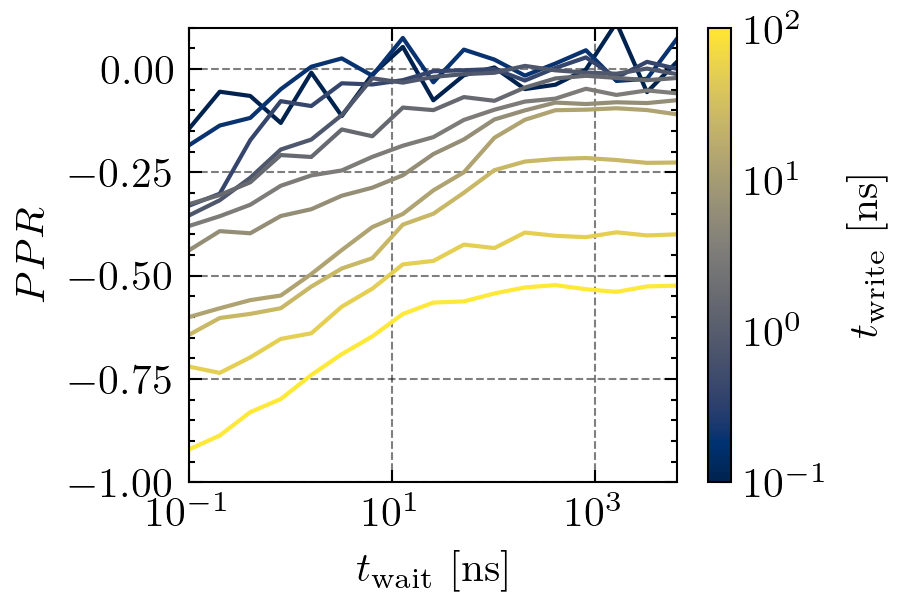

In [4]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.LogNorm(vmin=T_WRITES[0],vmax=T_WRITES[-1])
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
L       = 13
for i, t_write in enumerate(T_WRITES):
    x_plot  = np.array(T_WAITS).copy()[1:]
    y_plot  = np.array(mem_p[L][t_write]).copy()[1:]
    _       = ax.plot(x_plot, y_plot, label="$t_\\textrm{write}"+f" = {t_write}$ ns", ls='-', color=cmap(norm(t_write)))

_       = ax.set_xscale('log')
_       = ax.set_ylabel("$PPR$")
_       = ax.set_xlabel("$t_\\text{wait}~[\mathrm{ns}]$")
sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$t_\\text{write}~[\mathrm{ns}]$")
_       = ax.set_ylim(-1,0.1)
_       = ax.set_xlim(T_WAITS[1],T_WAITS[-1])

fig.savefig(f"plots/png/two_steps/N={L}_N={L}_PPR_vs_t_wait.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/N={L}_N={L}_PPR_vs_t_wait.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/N={L}_N={L}_PPR_vs_t_wait.svg", transparent=True)

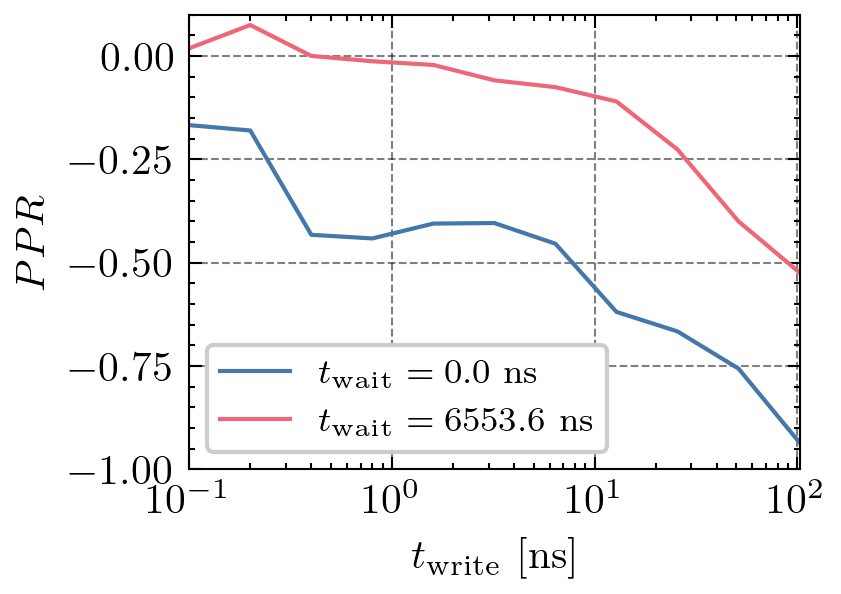

In [5]:
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
x_plot  = np.array(T_WRITES).copy()
for t_w_i in [0,-1]:
    y_plot  = np.array([mem_p[L][t_write][t_w_i] for t_write in T_WRITES]).copy()
    _       = ax.plot(x_plot, y_plot, label=f"$t_\\text{{wait}} = {T_WAITS[t_w_i]}~\mathrm{{ns}}$", ls='-')
_   = ax.set_xscale('log')
_   = ax.set_xlim(T_WRITES[0],T_WRITES[-1])
_   = ax.set_ylim(-1,0.1)
_   = ax.legend(fontsize='small', ncol=1)
_   = ax.set_ylabel("$PPR$")
_   = ax.set_xlabel("$t_\\textrm{write}$ [ns]")

fig.savefig(f"plots/png/two_steps/N={L}_N={L}_PPR_vs_t_write.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/N={L}_N={L}_PPR_vs_t_write.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/N={L}_N={L}_PPR_vs_t_write.svg", transparent=True)

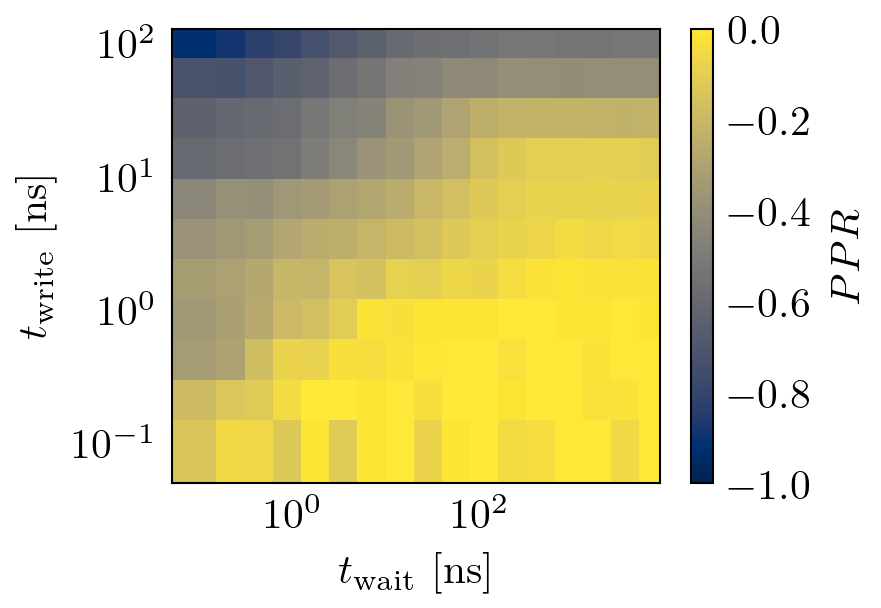

In [168]:
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
# mesh    = ax.imshow(np.array([mem_p[L][t1][1:] for t1 in T_WRITES]), extent=((T_WAITS[1],T_WAITS[-1],T_WRITES[0],T_WRITES[-1])), origin='lower', vmin=-1, vmax=0, cmap='cividis', aspect='auto')
mesh    = ax.pcolormesh(T_WAITS[1:], T_WRITES, np.array([mem_p[L][t1][1:] for t1 in T_WRITES]), vmin=-1, vmax=0, cmap='cividis', shading='nearest')
cb      = plt.colorbar(mesh, ax=ax, label="$PPR$")
_       = ax.set_xscale('log')
_       = ax.set_yscale('log')
_       = ax.set_xlabel("$t_\\textrm{wait}$ [ns]")
_       = ax.set_ylabel("$t_\\textrm{write}$ [ns]")

fig.savefig(f"plots/png/two_steps/N={L}_N={L}_PPR_memory_map.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/N={L}_N={L}_PPR_memory_map.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/N={L}_N={L}_PPR_memory_map.svg", transparent=True)

### L Dependence

In [6]:
def exp_decay(t, A, tau, beta, C):
    return A * np.exp(-((t / tau)**beta)) + C

taus = []
popts = []
for L in N_P_VALUES:
    initial_guess = [-0.73, 10.0, 1.0, -0.17]
    popt, pcov = curve_fit(exp_decay, np.array(T_WAITS)[1:], mem_p[L][T_WRITES[-1]][1:],
                           p0=initial_guess, bounds=((-np.inf,0,0,-np.inf),(0,20,1,0)))
    popts.append(popt)
    tau_fit = (popt[1] / popt[2]) * gamma(1 / popt[2])
    taus.append(tau_fit)

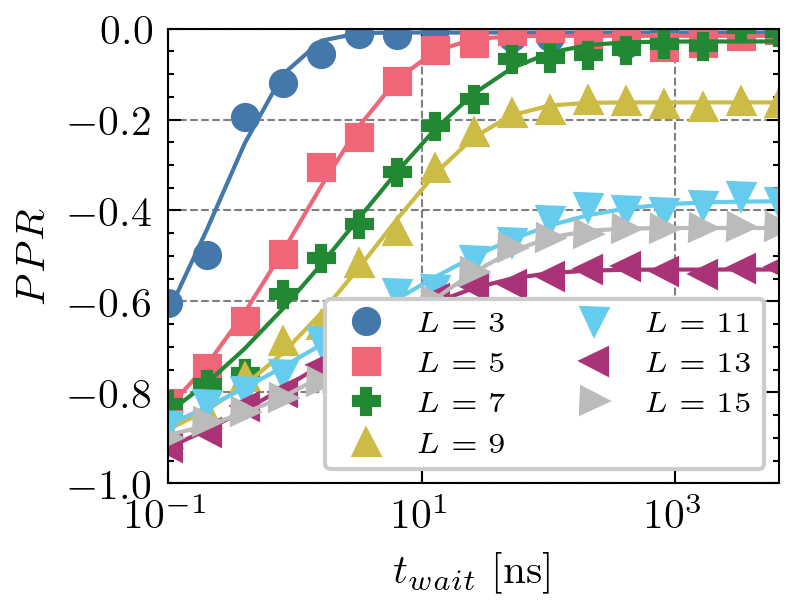

In [7]:
t_write = T_WRITES[-1]
fig     = plt.figure(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = fig.add_subplot()
markers = ['o','s','P','^','v','<','>']
for i, L in enumerate(N_P_VALUES):
    pp  = ax.plot(T_WAITS, mem_p[L][t_write], label=f'$L = {L}$', marker=markers[i], ls='')
    _   = ax.plot(T_WAITS, exp_decay(T_WAITS, *popts[i]), color=pp[0].get_color())
_       = ax.set_xscale('log')
_       = ax.set_ylim(-1,0)
_       = ax.set_xlim(T_WAITS[1],T_WAITS[-1])
_       = ax.set_xlabel("$t_{wait}~[\mathrm{ns}]$")
_       = ax.set_ylabel("$PPR$")
_       = ax.legend(fontsize='x-small', loc='lower right', ncol=2)

fig.savefig(f"plots/png/two_steps/PPR_vs_L.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/PPR_vs_L.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/PPR_vs_L.svg", transparent=True)

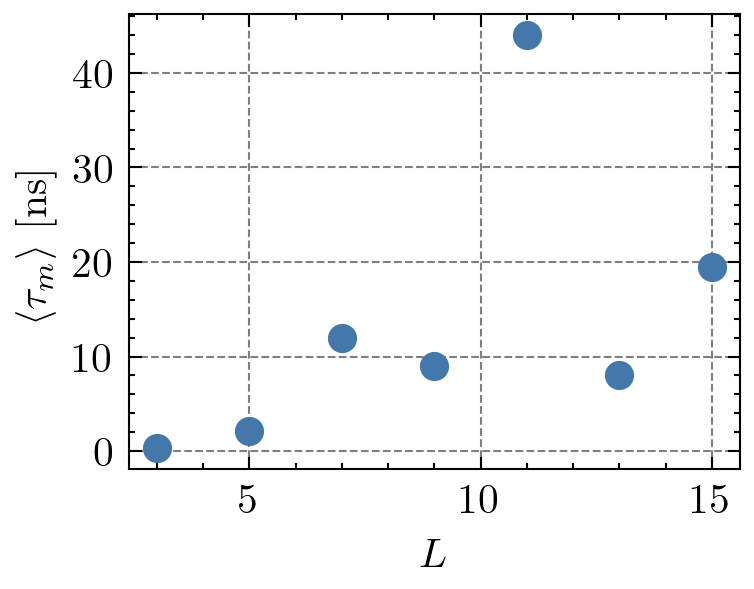

In [8]:
def lin_func(x, a, b):
    return a*x+b

fig     = plt.figure(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = fig.add_subplot()
popt, _ = curve_fit(lin_func, N_P_VALUES[1:], taus[1:])
pp      = ax.plot(N_P_VALUES, taus, marker='o', ls='')
# _       = ax.plot(np.array(N_P_VALUES[1:]), lin_func(np.array(N_P_VALUES[1:]),*popt), color=pp[0].get_color(), label=f'$\\langle\\tau_m\\rangle \sim {np.round(popt[0],2)}L$')
_       = ax.set_xlabel("$L$")
_       = ax.set_ylabel("$\\langle\\tau_m\\rangle~[\mathrm{ns}]$")
# _       = ax.legend(fontsize='small', loc='upper right')

fig.savefig(f"plots/png/two_steps/memory_time_vs_L.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/memory_time_vs_L.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/memory_time_vs_L.svg", transparent=True)

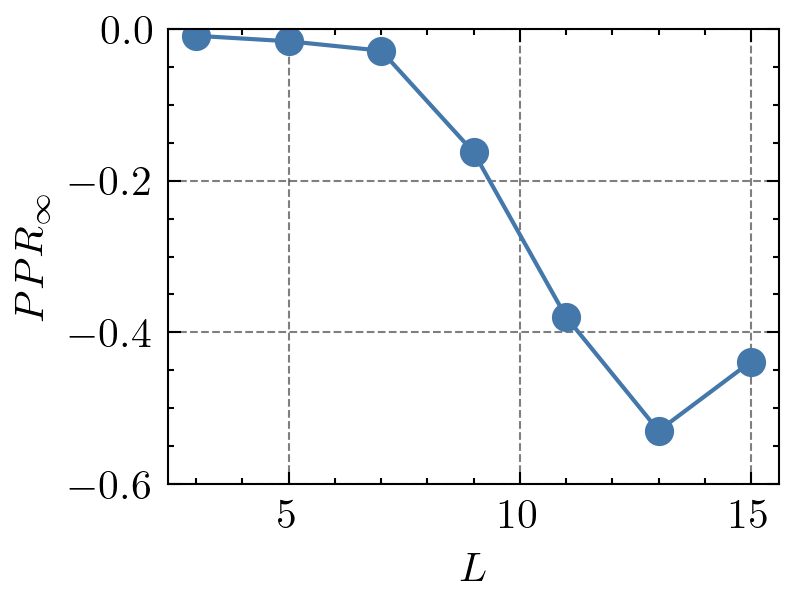

In [9]:
fig     = plt.figure(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = fig.add_subplot()
popt, _ = curve_fit(lin_func, N_P_VALUES[1:], taus[1:])
pp      = ax.plot(N_P_VALUES, np.array(popts)[:,-1], marker='o', ls='-')
_       = ax.set_xlabel("$L$")
_       = ax.set_ylabel("$PPR_\infty$")
_       = ax.set_ylim(-0.6,0)

fig.savefig(f"plots/png/two_steps/long_term_mem_vs_L.png", transparent=False)
fig.savefig(f"plots/pdf/two_steps/long_term_mem_vs_L.pdf", transparent=False)
fig.savefig(f"plots/svg/two_steps/long_term_mem_vs_L.svg", transparent=True)

### Writing Curve

In [ ]:
def get_t_crit(t_write_vals, ppi_curve, threshold=0.5):
    # 1. Create an interpolator function (f(t) = PPI)
    # We use linear interpolation between your discrete points
    # We flip the arrays because interp1d needs x to be strictly increasing
    f = interp1d(t_write_vals, ppi_curve, kind='linear')
    
    # 2. Find where it crosses 0.5
    # Since we want t where f(t)=0.5, and the function is monotonic decreasing,
    # we can just sweep or use a root finder. 
    # A simpler hack for monotonic data: interpolate the INVERSE function.
    
    # Safety: ensure curve actually crosses the threshold
    if np.min(ppi_curve) > threshold or np.max(ppi_curve) < threshold:
        return np.nan # Threshold not reached in this window
        
    f_inv = interp1d(ppi_curve, t_write_vals, kind='linear')
    
    return float(f_inv(threshold))

t_crits = []
start   = 3
for i, v_write in enumerate(V_WRITES):
    x_plot  = np.array(T_WRITES).copy()
    y_plot  = np.array([ppr_I[v_write][t_write][t_w_i] for t_write in T_WRITES]).copy()
    t_crit  = get_t_crit(x_plot[start:], y_plot[start:])
    t_crits.append(t_crit)

def one_over_V(x, a, b):
    return a*x**b

V_PLOT  = np.linspace(V_WRITES[0], V_WRITES[-1], 100)*1000
fig, ax = plt.subplots(dpi=200)
pp      = ax.plot(np.array(V_WRITES)*1000, t_crits, 'o')
popt, _ = curve_fit(one_over_V, np.array(V_WRITES)*1000, t_crits)
_       = ax.plot(V_PLOT, one_over_V(V_PLOT,*popt), '-', color=pp[0].get_color(),
                  label='$t_\\textrm{crit} \propto U_\\textrm{write}^'+'{'+f'{np.round(popt[1],2)}'+'}$')
# _       = ax.set_xscale('log')
# _       = ax.set_yscale('log')
_       = ax.legend()
_       = ax.set_xlabel('$U_\\textrm{write}$ [mV]')
_       = ax.set_ylabel("$t_\\textrm{crit}$ [ns]")

# fig.savefig(f"plots/png/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_t_crit_vs_U_write.png", transparent=False)
# fig.savefig(f"plots/pdf/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_t_crit_vs_U_write.pdf", transparent=False)
# fig.savefig(f"plots/svg/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_t_crit_vs_U_write.svg", transparent=True)

### I(t) Trace

In [ ]:
v_write = 0.01
t_write = 51.2
idx     = 25
x_vals  = x[v_write][t_write][idx]
t_vals  = t[v_write][t_write][idx]
tw1     = np.where(x_vals==0)[0][0]-1
tw2     = np.where(x_vals==0)[0][-1]+1

fig = plt.figure(dpi=200)
ax  = fig.add_subplot()
_   = ax.plot(t_vals[:-1], y[v_write][t_write][idx])
_   = ax.set_xlabel("$t$ [ns]")
_   = ax.set_ylabel("$I$ [pA]")
_   = ax.set_title(f'$U_w = {v_write*1000}$ mV, $t_w = {t_write}$ ns, '+'$t_{wait} = '+f'{T_WAITS[idx]}$ ns', fontsize='small')
# _   = ax.set_yscale('log')
_   = ax.set_ylim(0)
_   = plt.axvline(t_vals[tw1], color='black', ls='--', zorder=0.1, lw=0.8)
_   = plt.axvline(t_vals[tw2], color='black', ls='--', zorder=0.1, lw=0.8)

# fig.savefig(f"plots/png/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_out_response_Uw={v_write}_tw={t_write}_twa={T_WAITS[idx]}.png", transparent=False)
# fig.savefig(f"plots/pdf/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_out_response_Uw={v_write}_tw={t_write}_twa={T_WAITS[idx]}.pdf", transparent=False)
# fig.savefig(f"plots/svg/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_out_response_Uw={v_write}_tw={t_write}_twa={T_WAITS[idx]}.svg", transparent=True)

---

### Current based

In [ ]:
plt.imshow(p[9][T_WRITES[-1]][-3][50000,:].reshape(L,L), origin='lower', vmin=0, vmax=0.016)

In [ ]:
v_write = 0.04
fig, ax = plt.subplots(dpi=200)
mesh    = ax.pcolormesh(T_WAITS, T_WRITES, np.array([ppr_I[v_write][t1] for t1 in T_WRITES]), vmin=-1, vmax=1, cmap='coolwarm', shading='nearest')
cb      = plt.colorbar(mesh, ax=ax, label="$PPI_{\\langle q \\rangle}$")
_       = ax.set_xscale('log')
_       = ax.set_yscale('log')
_       = ax.set_xlabel("$t_\\textrm{wait}$ [ns]")
_       = ax.set_ylabel("$t_\\textrm{write}$ [ns]")

# fig.savefig(f"plots/png/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPI_q_map_{v_write}_q.png", transparent=False)
# fig.savefig(f"plots/pdf/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPI_q_map_{v_write}.pdf", transparent=False)
# fig.savefig(f"plots/svg/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPI_q_map_{v_write}.svg", transparent=True)

In [ ]:
T_W_VAL = [0.1,0.4,1.6,3.2,12.8,51.2]
markers = ['o','s','^','v','<','>']
fig, ax = plt.subplots(dpi=200)
v_write = 0.04
for i, t_write in enumerate(T_W_VAL):
    x_plot  = np.array(T_WAITS).copy()
    y_plot  = np.array(r_decay[v_write][t_write]).copy()
    ax.plot(x_plot, y_plot, label="$t_\\textrm{write}"+f" = {t_write}$ ns", ls='-', marker=markers[i])
_   = plt.axvline(28.5, label="$\\langle\\tau_\\textrm{corr}\\rangle$", color='black', ls='--', zorder=0.1)
_   = ax.set_xscale('log')
_   = ax.set_ylim(-0.1,1.0)
_   = ax.legend(fontsize='small', ncol=1, loc='upper right')#, title=f'$U_w = {1000*v_write}$ mV', title_fontsize='small')
_   = ax.set_ylabel("$R_{retained}$")
_   = ax.set_xlabel("$t_\\textrm{wait}$ [ns]")

# fig.savefig(f"plots/png/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPR_vs_t_wait_{v_write}_q.png", transparent=False)
# fig.savefig(f"plots/pdf/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPR_vs_t_wait_{v_write}.pdf", transparent=False)
# fig.savefig(f"plots/svg/two_steps/N={N_PARTICLES}_N={N_PARTICLES}_PPR_vs_t_wait_{v_write}.svg", transparent=True)